# ELOM OLUCHI LUCY
# Track: Data Analytics (Oasis Infobyte SIP)
# Task: Level 1 - Customer Segmentation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
df = pd.read_excel("retail_sales_dataset.xlsx")
df["Date"] = pd.to_datetime(df["Date"], unit="D", origin="1899-12-30")

print(df.shape, "| Missing:", df.isna().sum().sum(), "| Duplicates:", df.duplicated().sum())
print("Unique customers:", df["Customer ID"].nunique())
print("Purchases per customer:", len(df) / df["Customer ID"].nunique())
print("Average purchase value:", df["Total Amount"].mean())
df.head()

(1000, 9) | Missing: 0 | Duplicates: 0
Unique customers: 1000
Purchases per customer: 1.0
Average purchase value: 456.0


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


K = 1 | inertia: 3000.0
K = 2 | inertia: 2048.0
K = 3 | inertia: 1436.0
K = 4 | inertia: 1041.0
K = 5 | inertia: 850.5
K = 6 | inertia: 686.7
K = 7 | inertia: 596.1
K = 8 | inertia: 528.2


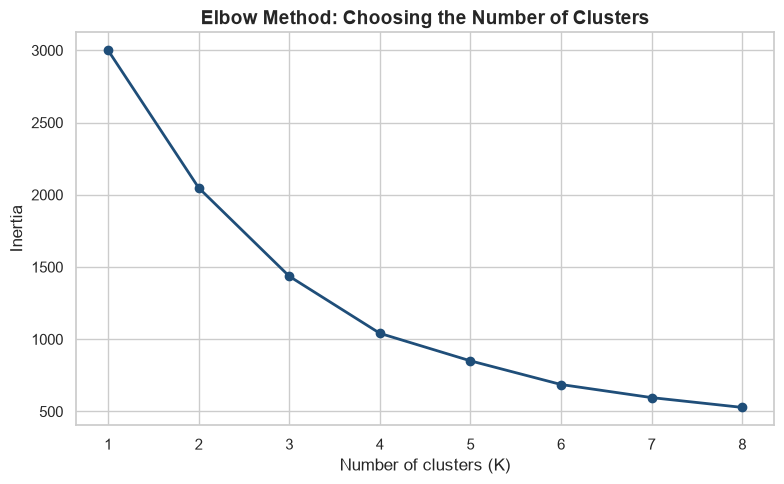

In [3]:
features = ["Age", "Quantity", "Total Amount"]
X = StandardScaler().fit_transform(df[features])

inertia = []
for k in range(1, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertia.append(km.inertia_)
    print("K =", k, "| inertia:", round(km.inertia_, 1))

plt.figure(figsize=(8, 5))
plt.plot(range(1, 9), inertia, marker="o", color="#1f4e79", linewidth=2)
plt.title("Elbow Method: Choosing the Number of Clusters", fontsize=14, fontweight="bold")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

         Customers  Avg_Age  Avg_Quantity  Avg_Total_Amount  Total_Revenue
Cluster                                                                   
0              283     52.3           1.5             233.1          65955
1              240     26.8           1.7             211.4          50740
2              228     39.6           3.4            1344.7         306600
3              249     44.6           3.6             131.3          32705


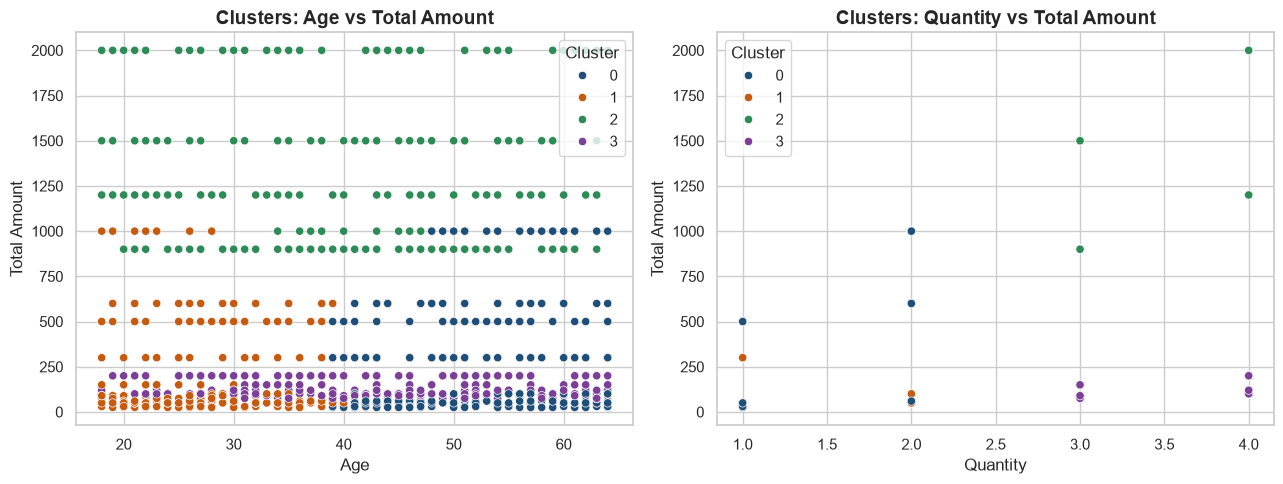

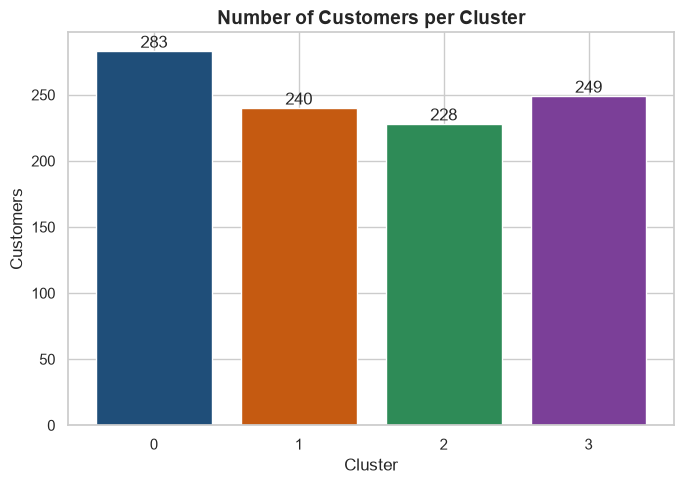

In [4]:
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X)
df["Cluster"] = km.labels_

profile = df.groupby("Cluster").agg(
    Customers=("Customer ID", "count"),
    Avg_Age=("Age", "mean"),
    Avg_Quantity=("Quantity", "mean"),
    Avg_Total_Amount=("Total Amount", "mean"),
    Total_Revenue=("Total Amount", "sum"),
).round(1)
print(profile)

palette = ["#1f4e79", "#c55a11", "#2e8b57", "#7b3f98"]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x="Age", y="Total Amount", hue="Cluster", palette=palette, ax=ax[0])
ax[0].set_title("Clusters: Age vs Total Amount", fontsize=14, fontweight="bold")
sns.scatterplot(data=df, x="Quantity", y="Total Amount", hue="Cluster", palette=palette, ax=ax[1])
ax[1].set_title("Clusters: Quantity vs Total Amount", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

counts = df["Cluster"].value_counts().sort_index()
plt.figure(figsize=(7, 5))
bars = plt.bar(counts.index.astype(str), counts.values, color=palette)
plt.bar_label(bars)
plt.title("Number of Customers per Cluster", fontsize=14, fontweight="bold")
plt.xlabel("Cluster")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

## Customer Segments and Marketing Recommendations

*Method:* K-Means clustering (K = 4) on Age, Quantity and Total Amount, after scaling with StandardScaler. The elbow chart bends gently with no sharp elbow, so K = 4 was chosen because it gives clear, usable groups. Silhouette scores were not used.

*Limitation:* each customer made only one purchase, so Recency, Frequency and customer lifetime value could not be calculated. Total Amount drives most of the separation between the groups.
    

| Cluster | Segment | Customers | Avg Age | Avg Quantity | Avg Total Amount | Share of revenue |
|---|---|---|---|---|---|---|
| 2 | High-value shoppers | 228 | 39.6 | 3.4 | 1,344.7 | 67.2% |
| 0 | Mature light spenders | 283 | 52.3 | 1.5 | 233.1 | 14.5% |
| 1 | Young light spenders | 240 | 26.8 | 1.7 | 211.4 | 11.1% |
| 3 | Bulk buyers of low-priced items | 249 | 44.6 | 3.6 | 131.3 | 7.2% |

*Recommended action for each segment*
1. *High-value shoppers (Cluster 2):* only 22.8% of customers but 67.2% of revenue. Protect them with a VIP or loyalty programme, early access to new products and premium bundles.
2. *Mature light spenders (Cluster 0):* older customers who buy few items at modest prices. Use email and in-store offers, loyalty points, and suggestions of higher-value products.
3. *Young light spenders (Cluster 1):* the youngest group, with small purchases. Use social media campaigns, student or first-purchase discounts and "trade-up" offers.
4. *Bulk buyers of low-priced items (Cluster 3):* they buy many items but spend little in total. Cross-sell and upsell higher-priced items, and use bundle deals or minimum-spend offers to raise the basket value.